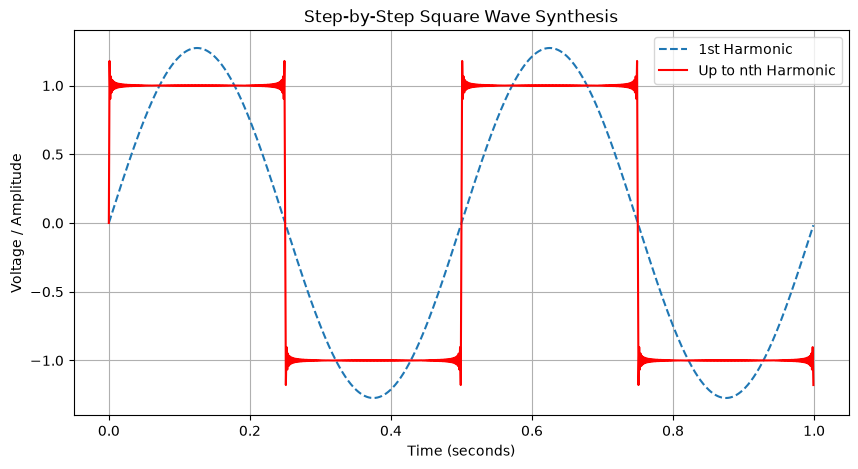

1000
500


C:\Users\lazar\AppData\Local\Temp\ipykernel_31620\2031132807.py:51: RuntimeWarning: divide by zero encountered in divide
  plt.plot(xf[:N//2], (4*f0/np.pi)/xf[:N//2], label='1/f', color='blue', alpha=0.6)


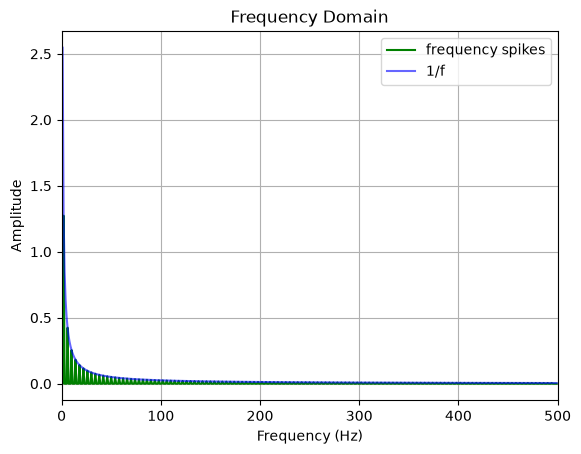

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

t = np.linspace(0, 1, 1000, endpoint=False)
f0 = 2
N=1000
fs = 1000

# Layer 1: Just the fundamental (1st Harmonic)
fundamental = (4 / np.pi) * np.sin(2 * np.pi * f0 * t) #1st harmonic

# Layer 2: Add the 3rd Harmonic
harmonic3 = fundamental + (4 / np.pi) * (np.sin(6 * np.pi * f0 * t) / 3)

# Layer 3: Add the 5th Harmonic
harmonic5 = harmonic3 + (4 / np.pi) * (np.sin(10 * np.pi * f0 * t) / 5)

# Layer 4: Add the 7th Harmonic
harmonic7 = harmonic5 + (4 / np.pi) * (np.sin(14 * np.pi * f0 * t) / 7)

# Layer 5: Add the 9th Harmonic
harmonicn = harmonic7 + (4 / np.pi) * (np.sin(18 * np.pi * f0 * t) / 9)

# Layer a bunch: Add a bunch of harmonics
n = 9
while n<=249:
    n = n + 2
    harmonicn = harmonicn + (4 / np.pi) * (np.sin(2*n * np.pi * f0 * t) / n)

# Plotting the progression
plt.figure(figsize=(10, 5))
plt.plot(t, fundamental, label="1st Harmonic", linestyle="--")
plt.plot(t, harmonicn, label="Up to nth Harmonic", color="red")
plt.title("Step-by-Step Square Wave Synthesis")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage / Amplitude")
plt.grid(True)
plt.legend()
plt.show()

#Frequency Content
fdomain = np.fft.fft(harmonicn)
print(len(fdomain))
intensities = np.abs(fdomain[:N//2]) * 2 / N
print(len(intensities))
xf = fftfreq(N, 1/fs)

graph_lim = min(n*f0*1.1, 500)
plt.plot(xf[:N//2], intensities, label='frequency spikes', color="green")
plt.plot(xf[:N//2], (4*f0/np.pi)/xf[:N//2], label='1/f', color='blue', alpha=0.6)
plt.title("Frequency Domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0, graph_lim)
plt.grid(True)
plt.legend()
plt.show()


In [2]:
import numpy as np

input = [0, 0, 1, 0, 0, 1, 0, 0, 1]
test = np.fft.fft(input)
print(test)
print(type(input))
print(type(test))
print(type(test[1]))

[ 3. +0.j          0. +0.j          0. +0.j         -1.5+2.59807621j
  0. +0.j          0. +0.j         -1.5-2.59807621j  0. +0.j
  0. +0.j        ]
<class 'list'>
<class 'numpy.ndarray'>
<class 'numpy.complex128'>


In [4]:
import numpy as np

argument = np.angle(complex(3 + 4j))
modulus = np.abs(complex(3 + 4j))
print(argument)
print(type(argument))
print(modulus)
print(type(modulus))

0.9272952180016122
<class 'numpy.float64'>
5.0
<class 'numpy.float64'>
